# Data Science Final Project
by: Christopher Yarbro and Lakeland Galinson


[Link to our github website](https://yarbschris.github.io/ds-final)

## Intro
Our names are Christopher Yarbro and Lakeland Galinson. We are seniors at Tulane University studying Computer Science. This website will host the code, figures, and anything else necessary for our Final Project in Data Science.

**The goal for this project** is to analyze New Orleans police report and calls data in conjunction with New Orleans regional demographic data to see if regional demographics like age, population growth, and income can be used to to predict police report and call volume

## Research Questions
1. How do reported crimes and 911 calls vary accross different districts of New Orleans?

2. Can a relationship between regional demographics and police reports be established?

3. Can regional demographic data be used to train a predictive model to assist policy makers and police forces who want to reduce crime?

These questions will guide both exploratory visualizations and later statistical testing in our final tutorial.

## Organization
Our first step was to create a git repository hosted on github that we can both access and edit. We are roommates, so we have been able to meet regularly to discuss our plans for the project.



## Data Sets

### New Orleans Police Department Calls for Service 2025
This dataset, provided by the Orleans Parish Communication District, shows instances of reports filed by phone to NOPD. It contains information about the type of report, the time it occured, and the location of the report. 

The dataset can be found [here](https://catalog.data.gov/dataset/calls-for-service-2025).



### New Orleans Electronic Police Reports 2025
This dataset is a collection of all police reports in 2025. It contains information about the location, type of report, date, and demographic information about the victim and offender.

The dataset can be found [here](https://data.nola.gov/Public-Safety-and-Preparedness/Electronic-Police-Report-2025/agqi-9adb/about_data).

With this dataset, we hope to answer questions regarding the **frequency of crime reports by geographic location**. In our final interactive visualization, data regarding crime type, demographics, etc will be available via tooltip. 

We will load, clean, and explore this dataset below.

### New Orleans Zip Code Data
This dataset contains Population, Population Growth, Average Age, and Income per Household data for every zipcode in New Orleans

The dataset can be found [here](https://localistica.com/usa/la/new%20orleans/zipcodes/most-populated-zipcodes/).

With this dataset, we hope to answer questions regarding how factors like age, population growth, and income per household are related to the number of police reports in a district.


In [527]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import math
import re

PARENT_DIR = os.getcwd()
DATA_DIR = os.path.join(PARENT_DIR, "data")

PATH_TO_POLICE_REPORTS = os.path.join(DATA_DIR, "ElectronicPoliceReport2025.csv")
police_reports = pd.read_csv(PATH_TO_POLICE_REPORTS)
police_reports.head()

,Item_Number,District,Location,Disposition,Signal_Type,Signal_Description,Occurred_Date_Time,Charge_Code,Charge_Description,Offender_Number,...,Offender_Gender,Offender_Age,Victim_Number,PersonType,Victim_Race,Victim_Gender,Victim_Age,Victim_Fatal_Status,Hate Crime,Report Type
0,F-07416-25,7,Chef Menteur Hw & Downman Rd,OPEN,966,DRUG LAW VIOLATION,2025-06-08 12:50:00,40 1023,PROHIBITED ACTS - DRUG PARAPHENALIA,1.0,...,MALE,32.0,1.0,VICTIM,NaN,NaN,NaN,Non-fatal,NaN,Supplemental Report
1,F-07416-25,7,Chef Menteur Hw & Downman Rd,OPEN,966,DRUG LAW VIOLATION,2025-06-08 12:50:00,40 967,PROHIBITED ACTS-- SCHEDULE II DRUGS,1.0,...,MALE,32.0,1.0,VICTIM,NaN,NaN,NaN,Non-fatal,NaN,Supplemental Report
2,F-07416-25,7,Chef Menteur Hw & Downman Rd,OPEN,966,DRUG LAW VIOLATION,2025-06-08 12:50:00,40 967,PROHIBITED ACTS-- SCHEDULE II DRUGS,1.0,...,MALE,32.0,1.0,VICTIM,NaN,NaN,NaN,Non-fatal,NaN,Supplemental Report
3,F-08297-25,3,Paris Av & Lafreniere St,OPEN,21,MISCELLANEOUS INCIDENT,2025-06-09 13:21:00,NaN,NaN,NaN,...,NaN,NaN,1.0,REPORTING PERSON,BLACK,FEMALE,36.0,Non-fatal,NaN,Incident Report
4,F-09102-25,3,025XX Gladiolus St,OPEN,103,DISTURBANCE,2025-06-10 09:30:00,NaN,NaN,NaN,...,NaN,NaN,2.0,INTERVIEW,BLACK,MALE,65.0,Non-fatal,NaN,Incident Report


Some quick descriptive statistics:

In [528]:
police_reports.describe()

,District,Offender_Number,OffenderID,Offender_Age,Victim_Number,Victim_Age
count,73307.000000,40182.000000,40182.000000,19502.000000,71730.000000,53782.000000
mean,4.944235,1.188443,953576.767732,35.193262,1.457438,40.458183
std,2.299061,0.953579,13141.873921,12.584696,0.986678,16.134032
min,1.000000,-1.000000,929934.000000,0.000000,1.000000,0.000000
25%,3.000000,1.000000,942671.500000,25.000000,1.000000,29.000000
50%,5.000000,1.000000,954402.500000,34.000000,1.000000,38.000000
75%,7.000000,1.000000,965421.750000,43.000000,2.000000,51.000000
max,8.000000,79.000000,974444.000000,94.000000,67.000000,125.000000


We have some cleaning up to do, let's start by removing supplemental reports:

In [529]:
police_reports.drop(police_reports[police_reports["Report Type"].str.contains("Supplemental Report")].index, inplace=True)


We can also drop some columns that are not of much value for our specific goals. We will keep a few temporarily for exploratory purposes.

In [530]:
colsToDrop = ["Item_Number", "Disposition", "Signal_Description", "Charge_Code", "Offender_Number", "Victim_Number", "PersonType", "Victim_Fatal_Status", "Hate Crime", "Report Type", "OffenderStatus", "OffenderID", "Offender_Race", "Offender_Gender", "Offender_Age", "Charge_Description"]

for col in colsToDrop:
    police_reports.drop(col, axis=1, inplace=True)

Let's make sure our df doesn't contain any null values.

In [531]:
police_reports.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60664 entries, 3 to 73306
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   District            60664 non-null  int64  
 1   Location            60664 non-null  object 
 2   Signal_Type         60664 non-null  object 
 3   Occurred_Date_Time  60664 non-null  object 
 4   Victim_Race         51494 non-null  object 
 5   Victim_Gender       51530 non-null  object 
 6   Victim_Age          45183 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 3.7+ MB


It looks like Victim Race, Victim Gender, and Victim Age all contain null values. In the case of race and gender, we may just have to drop these rows. For victim age, we can fill null values with the mean. Since these columns are not necessarily related to our first three main objectives, we will create a new dataframe.

In [532]:
# Copy df
reports_with_victim_info = police_reports.copy()

# Handle NaNs
for col in ["Victim_Race", "Victim_Gender"]:
    reports_with_victim_info[col] = reports_with_victim_info[col].replace("UNKNOWN", None)
    
reports_with_victim_info["Victim_Age"] = reports_with_victim_info["Victim_Age"].fillna(police_reports["Victim_Age"].mean())
reports_with_victim_info = reports_with_victim_info.dropna()

# Remove columns from main df
victimCols = ["Victim_Race", "Victim_Gender", "Victim_Age"]
for col in victimCols:
    police_reports.drop(col, axis=1, inplace=True)

In [533]:
reports_with_victim_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47515 entries, 3 to 73306
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   District            47515 non-null  int64  
 1   Location            47515 non-null  object 
 2   Signal_Type         47515 non-null  object 
 3   Occurred_Date_Time  47515 non-null  object 
 4   Victim_Race         47515 non-null  object 
 5   Victim_Gender       47515 non-null  object 
 6   Victim_Age          47515 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


Let's find the Average Age of the victims:

In [534]:
print(f'Mean Average Age: {reports_with_victim_info["Victim_Age"].mean()}')

Mean Average Age: 40.629519682033695


We can also find the standard deviation:

In [535]:
print(f'Standard Deviation of Age: {reports_with_victim_info["Victim_Age"].std()}')

Standard Deviation of Age: 15.48388450778885


[Text(0, 0.5, 'Race of Victim')]

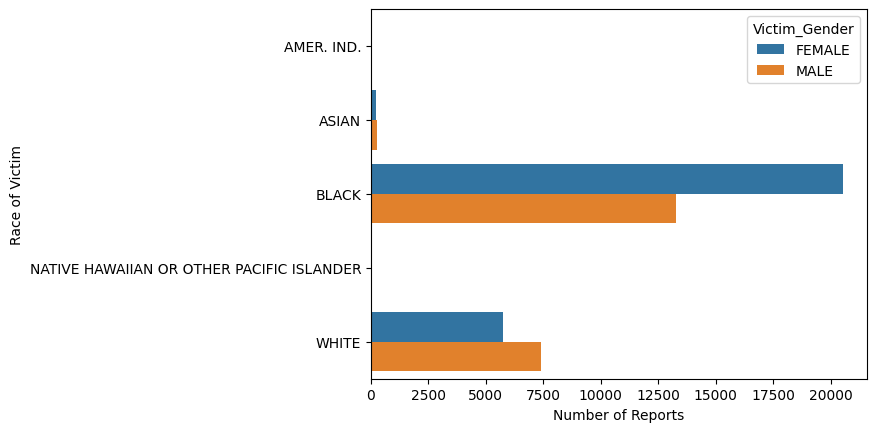

In [536]:
reports_by_race_gender = reports_with_victim_info.groupby(["Victim_Race", "Victim_Gender"]).size().reset_index(name="Number of Reports")
ax = sns.barplot(reports_by_race_gender, y="Victim_Race", x="Number of Reports", hue="Victim_Gender")
ax.set(ylabel = "Race of Victim")

We can see that black women make up an extremely high proportion of victims. However, we cannot see any data for American Indian or Naitive Hawaiian victims, so lets take the log and see if we can get a better look. This will compress the x axis so that we can view populations with very low counts on the same chart as populations with very high counts, but it does NOT change the actual data. This is purely for visualization.

[Text(0, 0.5, 'Race of Victim'), Text(0.5, 0, 'Number of Reports (log)')]

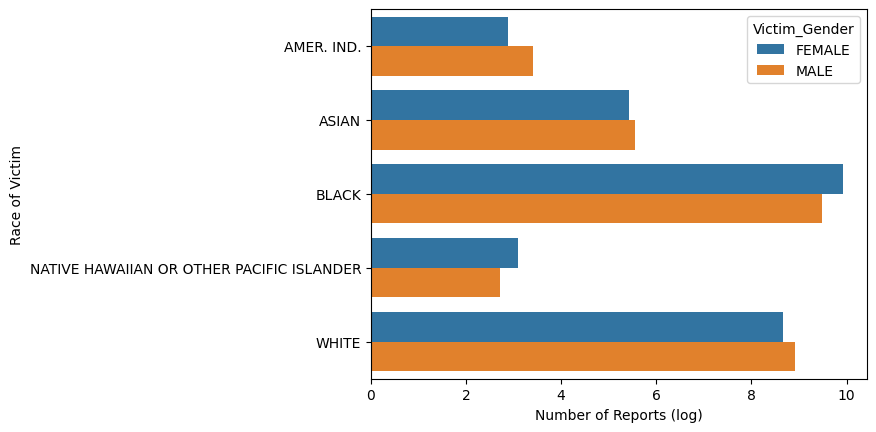

In [537]:
reports_by_race_gender["Number of Reports"] = reports_by_race_gender["Number of Reports"].apply(math.log)
ax = sns.barplot(reports_by_race_gender, y="Victim_Race", x="Number of Reports", hue="Victim_Gender")
ax.set(ylabel = "Race of Victim", xlabel= "Number of Reports (log)")

 Much better

Next we will group the data by month.

In [538]:
def isolate_year_month(entry):
    date_time_pattern = r"^\d{4}-(\d{2})-\d{2}\s\d{2}:\d{2}:\d{2}$" # Parentheses around the part of the pattern that will match the month
    return re.sub(date_time_pattern, r"\1", entry) # We use the first match to replace the entire string.

In [539]:
police_reports["Occurred_Date_Time"] = police_reports["Occurred_Date_Time"].apply(isolate_year_month)

In [540]:
police_reports["Occurred_Date_Time"].value_counts()

Occurred_Date_Time
08    6538
09    6429
03    6388
10    6386
07    6206
04    6000
05    5997
06    5558
02    5284
01    5106
11     772
Name: count, dtype: int64

**Note: Data is incomplete because it is from this year, but by the time project is turned in we should have almost a full year of data available**

[Text(0.5, 0, 'Month'), Text(0, 0.5, 'Number of Reports')]

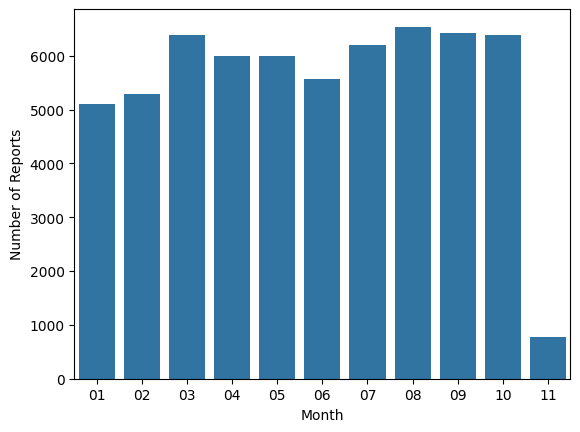

In [541]:
reports_by_month = police_reports.groupby("Occurred_Date_Time")
ax = sns.barplot(reports_by_month.size())
ax.set(xlabel="Month", ylabel="Number of Reports")

We can see two peaks, one in March and one in August. The full month that has the lowest number of reports is January.

Let's explore the data a bit more. We'll start by seeing how many reports were filed in each district.

In [542]:
reports_by_district = police_reports.groupby("District")
reports_by_district.size()

District
1     6366
2     5680
3     6751
4     5540
5     8058
6     7716
7    11607
8     8946
dtype: int64

We can make this into a bar chart to vizualize it better.

[Text(0, 0.5, 'Number of Reports')]

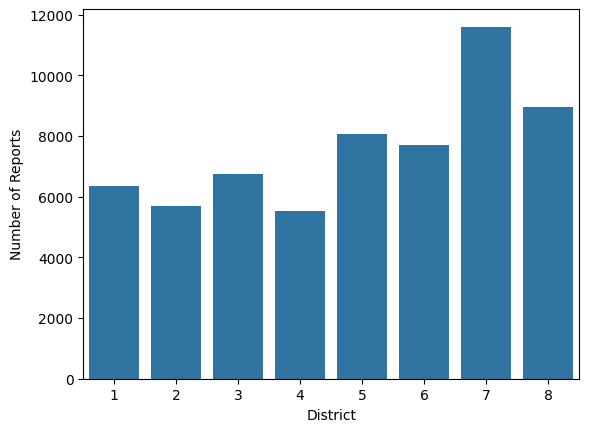

In [543]:
ax = sns.barplot(reports_by_district.size())
ax.set(ylabel="Number of Reports")

As we can see, the highest frequency of crime reports occurs in District 7. In future milestones we will explore why this might be and include an interactive map to display these statistics.

## Loading in a second data set (Milestone 2)
To get more context on police reports, we will load in our second dataset, **New Orleans Police Department Calls for Service 2025**

In [544]:
PATH_TO_CALLS_FOR_SERVICE = os.path.join(DATA_DIR, "CallsForService2025.csv")
calls_for_service = pd.read_csv(PATH_TO_CALLS_FOR_SERVICE)
calls_for_service.head()

,NOPD_Item,Type,TypeText,Priority,InitialType,InitialTypeText,InitialPriority,MapX,MapY,TimeCreate,...,TimeArrive,TimeClosed,Disposition,DispositionText,SelfInitiated,Beat,BLOCK_ADDRESS,Zip,PoliceDistrict,Location
0,B1105225,21J,MISSING JUVENILE,1,21J,MISSING JUVENILE,2F,37369000,3513814,2025-02-11T22:48:15.970000,...,2025-02-12T03:56:09.213000,2025-02-12T06:01:17.150000,RTF,REPORT TO FOLLOW,N,7D02,064XX Chestershire Dr,70126.0,7,POINT (0 0)
1,E1305925,52,SIMPLE ARSON,1D,21,COMPLAINT OTHER,1F,3669577,535978,2025-05-14T09:46:47.553000,...,2025-05-14T11:08:34.473000,2025-05-14T16:06:04.473000,RTF,REPORT TO FOLLOW,N,1K02,040XX Tulane Av,70119.0,1,POINT (-90.10556551 29.96811038)
2,F0608625,35D,SIMPLE BATTERY DOMESTIC,2C,103D,DOMESTIC DISTURBANCE,1A,3668911,532344,2025-06-06T22:16:37.057000,...,2025-06-08T08:13:39.363000,2025-06-08T11:08:07.127000,RTF,REPORT TO FOLLOW,N,2V03,032XX Bloomingdale Ct,70125.0,2,POINT (-90.10779393 29.9581383)
3,F0617425,103D,DOMESTIC DISTURBANCE,1A,103D,DOMESTIC DISTURBANCE,2C,3660638,531179,2025-06-07T00:58:44.983000,...,2025-06-08T05:12:11.927000,2025-06-08T05:55:23.387000,RTF,REPORT TO FOLLOW,N,2K02,015XX General Ogden St,70118.0,2,POINT (-90.13395361 29.95517682)
4,E1452725,103F,FIGHT,2D,35,SIMPLE BATTERY,2E,3679264,521299,2025-05-15T17:32:47.277000,...,2025-05-15T17:37:25.593000,2025-05-15T19:09:12.410000,RTF,REPORT TO FOLLOW,N,6A06,008XX Jackson Av,70130.0,6,POINT (-90.07548229 29.92745961)


Some quick descriptive statistics:

In [545]:
calls_for_service.describe()

,MapX,MapY,Zip,PoliceDistrict
count,3.037310e+05,3.037310e+05,298614.000000,303731.000000
mean,5.105811e+06,6.618291e+05,70120.802635,4.461013
std,6.857015e+06,6.075143e+05,5.851568,2.369630
min,0.000000e+00,-8.230700e+04,70112.000000,0.000000
25%,3.672900e+06,5.291330e+05,70116.000000,3.000000
50%,3.681168e+06,5.358250e+05,70119.000000,4.000000
75%,3.693772e+06,5.488740e+05,70126.000000,7.000000
max,3.736900e+07,3.513814e+06,70148.000000,8.000000


We can see that many of the categorical variables are being treated as nominal or ordinal values. Zipcode, PoliceDistrict, and map coordinates are numerical values, but performing operations on them is not meaninful. Lets convert them to objects. In fact, there are no variables where operations are meaningful, so we convert all columns to objects.

In [546]:
calls_for_service = calls_for_service.astype(object)
calls_for_service.dtypes

NOPD_Item          object
Type               object
TypeText           object
Priority           object
InitialType        object
InitialTypeText    object
InitialPriority    object
MapX               object
MapY               object
TimeCreate         object
TimeDispatch       object
TimeArrive         object
TimeClosed         object
Disposition        object
DispositionText    object
SelfInitiated      object
Beat               object
BLOCK_ADDRESS      object
Zip                object
PoliceDistrict     object
Location           object
dtype: object

Let's clean the data. For the purposes of our analysis, we will only need the following variables:
- TypeText (the type of crime)
- BLOCK_ADDRESS
- TimeCreate (just to get the month)
- PoliceDistrict

In [547]:
columns_to_drop = ['NOPD_Item', 'TypeText', 'Priority',
                   'InitialType', 'InitialTypeText', 'InitialPriority',
                    'TimeDispatch', 'TimeArrive',
                   'TimeClosed', 'Disposition', 'DispositionText',
                   'SelfInitiated', 'Beat', 'Location', 'MapX', 'MapY', "Zip"]

clean_calls_for_service = calls_for_service.drop(columns=columns_to_drop, axis=1)
clean_calls_for_service = clean_calls_for_service.drop(clean_calls_for_service.loc[clean_calls_for_service["PoliceDistrict"] == 0].index)
clean_calls_for_service = clean_calls_for_service[["PoliceDistrict", "BLOCK_ADDRESS", "Type", "TimeCreate"]]

clean_calls_for_service.head()

,PoliceDistrict,BLOCK_ADDRESS,Type,TimeCreate
0,7,064XX Chestershire Dr,21J,2025-02-11T22:48:15.970000
1,1,040XX Tulane Av,52,2025-05-14T09:46:47.553000
2,2,032XX Bloomingdale Ct,35D,2025-06-06T22:16:37.057000
3,2,015XX General Ogden St,103D,2025-06-07T00:58:44.983000
4,6,008XX Jackson Av,103F,2025-05-15T17:32:47.277000


We also want the TimeCreate column to only show the date, so lets edit our regular expression to extract just the month like we did in our other dataset:


In [548]:
def isolate_year_month_2(entry):
    pattern = r"^\d{4}-(\d{2})-\d{2}T\d{2}:\d{2}:\d{2}(?:\.\d+)?"
    return re.sub(pattern, r"\1", entry)

clean_calls_for_service["TimeCreate"] = clean_calls_for_service["TimeCreate"].apply(isolate_year_month_2)
clean_calls_for_service.head()
police_reports.head()

,District,Location,Signal_Type,Occurred_Date_Time
3,3,Paris Av & Lafreniere St,21,06
4,3,025XX Gladiolus St,103,06
5,7,078XX Read Bd,103D,06
6,7,078XX Read Bd,103D,06
7,3,025XX Gladiolus St,103,06


Now let's rename the columns to be the same as our other dataset:

In [549]:
clean_calls_for_service = clean_calls_for_service.rename(columns={"PoliceDistrict":"District", "BLOCK_ADDRESS":"Location", "Type":"Signal_Type", "TimeCreate":"Occurred_Date_Time"})
clean_calls_for_service.head()

,District,Location,Signal_Type,Occurred_Date_Time
0,7,064XX Chestershire Dr,21J,02
1,1,040XX Tulane Av,52,05
2,2,032XX Bloomingdale Ct,35D,06
3,2,015XX General Ogden St,103D,06
4,6,008XX Jackson Av,103F,05


Now that our two datasets have the same structures, let's combine them into a single dataframe. 

In [550]:
calls_and_reports = pd.concat([police_reports, clean_calls_for_service], ignore_index=True)


print(f'Shape of first dataframe: {police_reports.shape}\n')
print(f'Shape of first dataframe: {clean_calls_for_service.shape}\n')
print(f'Shape of COMBINED dataframe: {calls_and_reports.shape}')



Shape of first dataframe: (60664, 4)

Shape of first dataframe: (300652, 4)

Shape of COMBINED dataframe: (361316, 4)


Now lets use a third dataset to assign each of the signal types ("crime codes") to a readable crime description that are consistent between datasets. This dataset was sourced from [here](https://nola.gov/nola/media/NOPD/Policies/Chapter-81-7-Police-Complaint-Signals-and-Dispositions-EFFECTIVE-1-14-18.pdf), and maps each crime signal to plain english text of the crime. Since this is a PDF, we had AI parse through the document and create a CSV file that pandas can read. 


In [551]:
PATH_TO_SIGNALS = os.path.join(DATA_DIR, "crime_signal_codes.csv")
signals = pd.read_csv(PATH_TO_SIGNALS)
signals.head()

,Signal,Description
0,15,CITIZEN HOLDING A SUSPECT
1,17F,FUGITIVE ATTACHMENT
2,17J,JUVENILE ATTACHMENT
3,17M,MUNICIPAL COURT ATTACHMENT
4,17R,WARRANT STOP AND RELEASE


In [552]:
# create a mapping 
lookup = dict(zip(signals["Signal"], signals["Description"]))

# apply mapping
calls_and_reports["SignalDescription"] = calls_and_reports["Signal_Type"].map(lookup)

# rename columns for consistency
calls_and_reports = calls_and_reports.rename(columns={"SignalDescription":"Signal_Description", "Occurred_Date_Time":"Occurred_Month"})

# reorganize columns
calls_and_reports = calls_and_reports[["District", "Location", "Signal_Type", "Signal_Description", "Occurred_Month"]]

# drop duplicate entries (same reports)
calls_and_reports = calls_and_reports.drop_duplicates().reset_index(drop=True)
calls_and_reports.head()



,District,Location,Signal_Type,Signal_Description,Occurred_Month
0,3,Paris Av & Lafreniere St,21,COMPLAINT,06
1,3,025XX Gladiolus St,103,DISTURBANCE,06
2,7,078XX Read Bd,103D,"DISTURBANCE, DOMESTIC",06
3,6,022XX Jackson Av,43MB,NaN,06
4,2,082XX Earhart Bd,67S,THEFT BY SHOPLIFTING,06


Now that we have this dataframe, lets try to get a bit more information about the districts we are talking about. Unfortunately, our police data is divided by police districts, while most available data is divided by zip code. However, we can create a rough mapping of zip codes to district. While it is not perfect, most police district boundaries are also zip code boundaries.

The zip code data can be found [here](https://localistica.com/usa/la/new%20orleans/zipcodes/most-populated-zipcodes/).

First, we will retrieve the zip code data using requests and beautifulsoup

In [553]:
import requests
from bs4 import BeautifulSoup
from io import StringIO

r = requests.get("https://localistica.com/usa/la/new%20orleans/zipcodes/most-populated-zipcodes/")

We'll go ahead and save the content to a file since the website could go down or the data could become unavailable in the future. Once the content is downloaded, we will comment out the code we used to download the content to prevent overwriting the file in the future.

In [554]:
#with open("data/zipCodeRequestContent.txt", "w", encoding="utf-8") as f:
#    f.write(str(r.content))

Now we will reopen the file and read its contents and use BeautifulSoup to parse the content as we normally did in class.

In [555]:
with open("data/zipCodeRequestContent.txt") as f:
    content = f.read()

soup = BeautifulSoup(content)

We'll use beautifulsoup's find_all() function to isolate the table we want.

In [556]:
table = soup.find_all("table")

# Remove escape characters from text
clean_html = str(table).replace("\\r", "").replace("\\n", "").replace("\\t", "")

# Wrap in StringIO object to prevent error from pandas
clean_html = StringIO(clean_html)

# Read into dataframe using html, set header = 0 so our column titles are headers.
zipTable = pd.read_html(clean_html, header=0)[0].drop("City", axis=1)

In [557]:
zipTable

,ZipCode,Population,Growth,Age,Income per household
0,70119,39886.0,9%,34.2,"$21,297.00"
1,70115,35705.0,11%,36.6,"$27,094.00"
2,70122,33995.0,15%,36.9,"$31,104.00"
3,70118,33333.0,0%,30.0,"$28,006.00"
4,70117,30675.0,23%,37.6,"$19,567.00"
5,70126,28889.0,17%,32.4,"$30,627.00"
6,70131,28495.0,-4%,35.7,"$45,592.00"
7,70123,28303.0,6%,43.1,"$45,596.00"
8,70114,26655.0,14%,34.7,"$23,379.00"
9,70127,24481.0,16%,30.6,"$30,954.00"


Looks okay, but we can drop the unused rows

In [558]:
unusedCols = range(19,24)
zipTable = zipTable.drop(unusedCols)

In [559]:
zipTable

,ZipCode,Population,Growth,Age,Income per household
0,70119,39886.0,9%,34.2,"$21,297.00"
1,70115,35705.0,11%,36.6,"$27,094.00"
2,70122,33995.0,15%,36.9,"$31,104.00"
3,70118,33333.0,0%,30.0,"$28,006.00"
4,70117,30675.0,23%,37.6,"$19,567.00"
5,70126,28889.0,17%,32.4,"$30,627.00"
6,70131,28495.0,-4%,35.7,"$45,592.00"
7,70123,28303.0,6%,43.1,"$45,596.00"
8,70114,26655.0,14%,34.7,"$23,379.00"
9,70127,24481.0,16%,30.6,"$30,954.00"


Now we will match districts with zip code. Although this is not perfect, it lines up reasonably well for our puposes.
The Police Districts map can be found [here](https://nola.gov/next/nopd/about/police-districts/). This map was cross referenced with a map of New Orleans zip codes.

In [560]:
districtToZip = {1: [70119], 2: [70118, 70125], 3: [70124, 70122], 4: [70114, 70131], 5:[70117, 70126], 6:[70115, 70113, 70130], 7:[70127, 70128, 70129], 8:[70116,70112]}

In [561]:
# Create a dictionary that maps each zip code to its district so that we can apply it to our table
zipToDistrict = {
    zip_code: district
    for district, zips in districtToZip.items()
    for zip_code in zips
}


Let's clean up the data, we need to add the district column, remove a few rows, and format and correctly type some of the columns. All operations are explained in comments

In [562]:
# Use map to apply our dictionary to every value in the zipcode column and create a new column for district
zipTable["District"] = zipTable["ZipCode"].map(zipToDistrict)

# 70123 and 70121 are in Jefferson and are not covered by an NOPD district, so we will drop them
zipTable = zipTable.drop(zipTable.loc[(zipTable["ZipCode"] == 70123)].index)
zipTable = zipTable.drop(zipTable.loc[(zipTable["ZipCode"] == 70121)].index)

# convert district to integers
zipTable = zipTable.astype({'District': 'int32', 'Population': 'int32'})

# extract growth percentages and convert them to floating point numbers out of 100
zipTable["Growth"] = zipTable["Growth"].str.extract(f'(-?[0-9]+)').astype(float) / 100

# Extract income per household from string and convert to floating point
zipTable["Income per household"] = zipTable["Income per household"].str.extract('((?:[0-9]+,)?[0-9]+.[0-9]+)')
zipTable["Income per household"] = zipTable["Income per household"].str.replace(',', '').astype(float)

# To weight income per household by population in the next step
zipTable["Weighted Income per Household"] = zipTable["Income per household"] * zipTable["Population"]


Let's look at our newly cleaned dataframe and its types

In [563]:
zipTable

,ZipCode,Population,Growth,Age,Income per household,District,Weighted Income per Household
0,70119,39886,0.09,34.2,21297.0,1,8.494521e+08
1,70115,35705,0.11,36.6,27094.0,6,9.673913e+08
2,70122,33995,0.15,36.9,31104.0,3,1.057380e+09
3,70118,33333,0.00,30.0,28006.0,2,9.335240e+08
4,70117,30675,0.23,37.6,19567.0,5,6.002177e+08
5,70126,28889,0.17,32.4,30627.0,5,8.847834e+08
6,70131,28495,-0.04,35.7,45592.0,4,1.299144e+09
8,70114,26655,0.14,34.7,23379.0,4,6.231672e+08
9,70127,24481,0.16,30.6,30954.0,7,7.577849e+08
10,70124,19561,0.13,36.9,51684.0,3,1.010991e+09


In [564]:
zipTable.dtypes

ZipCode                            int64
Population                         int32
Growth                           float64
Age                              float64
Income per household             float64
District                           int32
Weighted Income per Household    float64
dtype: object

Now that this table is clean, we can group our table by district and scale some of the features by population to get a more holistic look at each district

In [565]:
districtGroupby = zipTable.groupby("District")

In [566]:
# The columns we will want to use
pop = districtGroupby['Population'].sum()
growth = districtGroupby['Growth'].mean().round(2)
age = districtGroupby['Age'].mean().round(2)

# Calculating the income per household weighted by population of each zip code, include_groups = False silences warning and gives same result
income = districtGroupby.apply(lambda x: x["Weighted Income per Household"].sum() / x["Population"].sum(), include_groups=False).round(2)
income.name = "Income per Household"

# Join these series together to get one districts dataframe
dfDistricts = pd.concat([pop, age, growth, income], axis = 1).reset_index()

# rename growth for clarity
dfDistricts = dfDistricts.rename(columns={"Growth":"Population_Growth"})

Great! Now we have more data to work with, and we can use this quantitative data to help develop a model, an aspect which we were missing in Milestone 1.

Here is all of the data we have so far:

In [567]:
display(dfDistricts)
display(calls_and_reports)

,District,Population,Age,Population_Growth,Income per Household
0,1,39886,34.20,0.09,21297.00
1,2,49134,30.50,0.04,25459.97
2,3,53556,36.90,0.14,38620.72
3,4,55150,35.20,0.05,34856.05
4,5,59564,35.00,0.20,24931.19
5,6,60855,36.97,0.14,24839.29
6,7,54108,32.57,0.13,35092.83
7,8,18511,37.35,0.20,17408.99


,District,Location,Signal_Type,Signal_Description,Occurred_Month
0,3,Paris Av & Lafreniere St,21,COMPLAINT,06
1,3,025XX Gladiolus St,103,DISTURBANCE,06
2,7,078XX Read Bd,103D,"DISTURBANCE, DOMESTIC",06
3,6,022XX Jackson Av,43MB,NaN,06
4,2,082XX Earhart Bd,67S,THEFT BY SHOPLIFTING,06
...,...,...,...,...,...
217947,6,S Claiborne Av & Josephine St,20I,INJURY ACCIDENT,08
217948,1,006XX Blk S Telemachus St,21,COMPLAINT,08
217949,5,St Roch Av & N Villere St,21,COMPLAINT,08
217950,5,020XX Blk Louisa St,21,COMPLAINT,08


In [568]:
calls_and_reports["District"].value_counts()

District
3    37190
7    32015
8    28264
6    27535
1    27280
5    26783
2    20623
4    18262
Name: count, dtype: int64

### Exploratory Data Analysis

Let's delve deeper into the data that we have.

First, let's add a new column to the District Data table that has the total number of reports in each district.

In [569]:
reportCountByDistrict = calls_and_reports.groupby("District")["Location"].count()

In [570]:
dfDistricts = dfDistricts.merge(reportCountByDistrict, on="District")
dfDistricts = dfDistricts.rename(columns={"Location": "NumReports"})

In [571]:
dfDistricts 

,District,Population,Age,Population_Growth,Income per Household,NumReports
0,1,39886,34.20,0.09,21297.00,27280
1,2,49134,30.50,0.04,25459.97,20623
2,3,53556,36.90,0.14,38620.72,37190
3,4,55150,35.20,0.05,34856.05,18262
4,5,59564,35.00,0.20,24931.19,26783
5,6,60855,36.97,0.14,24839.29,27535
6,7,54108,32.57,0.13,35092.83,32015
7,8,18511,37.35,0.20,17408.99,28264


Let's get some basic summary statistics:

In [572]:
dfDistricts.describe().T

,count,mean,std,min,25%,50%,75%,max
District,8.0,4.50000,2.449490,1.00,2.7500,4.500,6.2500,8.00
Population,8.0,48845.50000,13883.605604,18511.00,46822.0000,53832.000,56253.5000,60855.00
Age,8.0,34.83625,2.379489,30.50,33.7925,35.100,36.9175,37.35
Population_Growth,8.0,0.12375,0.060695,0.04,0.0800,0.135,0.1550,0.20
Income per Household,8.0,27813.25500,7490.884933,17408.99,23953.7175,25195.580,34915.2450,38620.72
NumReports,8.0,27244.00000,5946.646354,18262.00,25243.0000,27407.500,29201.7500,37190.00


### Income v. Number of Reports by District

Let's first examine the relationship between Income and Number of Reports by district (note, report count data is not yet scaled by population, we will save that for our final submission)

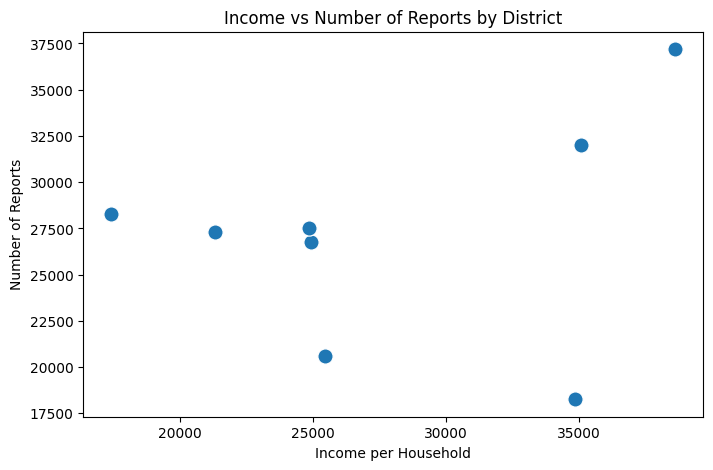

In [573]:
plt.figure(figsize=(8,5))
sns.scatterplot(dfDistricts, x="Income per Household", y="NumReports", s=120)
plt.title("Income vs Number of Reports by District")
plt.xlabel("Income per Household")
plt.ylabel("Number of Reports")
plt.show()

We can see that number of reports and income do not seem to be correlated. As income per household increases, the number of reports does not consistently rise or fall.

### Population Growth by District

Now we will visualize population growth by district. This will give us a better understanding of the districts and help us to compare them side by side.

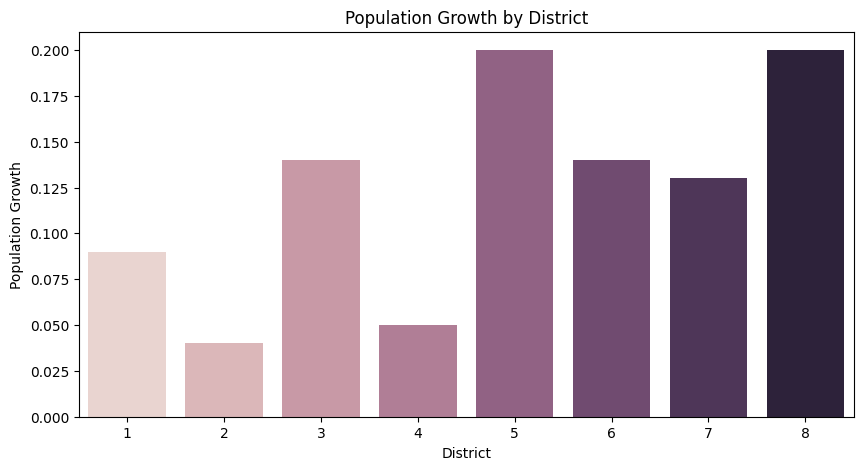

In [574]:
plt.figure(figsize=(10,5))
sns.barplot(dfDistricts, x="District", y="Population_Growth", hue="District", legend=False)
plt.title("Population Growth by District")
plt.ylabel("Population Growth")
plt.show()

Here we can see that districs 3 and 8 have significantly higher population growth rates than the other districts, sharing nearly identical growth rates. Districts 2 and 4 have significantly lower rates. This data might be helpful in our analysis to get a better understanding of which features can actually predict crime rates.

### Correlation Heatmap of District Metrics

Let's do a correlation heatmap to find any correlations that we may not have expected and help us better understand our data.

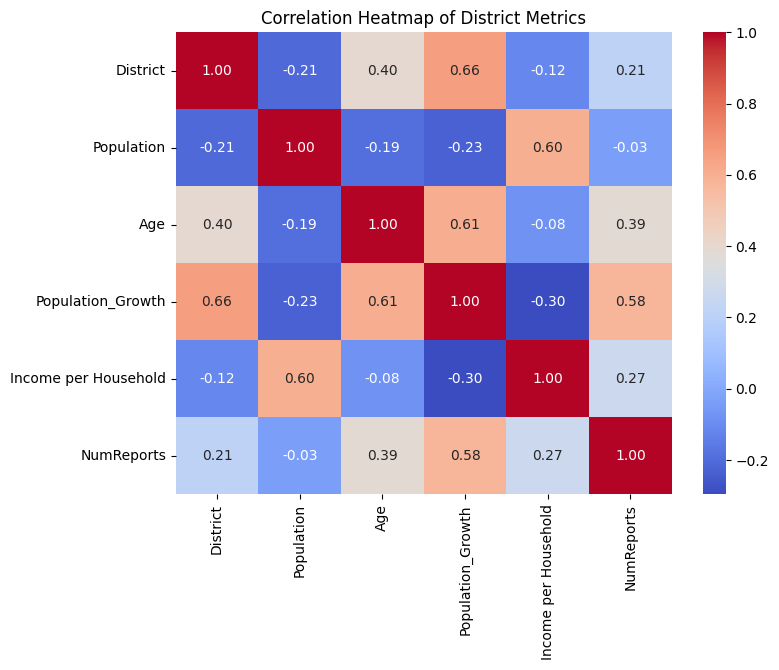

In [575]:
plt.figure(figsize=(8,6))
sns.heatmap(dfDistricts.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of District Metrics")
plt.show()

Here we can see the correlation between different features of a district. Population growth and Age are positively correlated, along with population growth and number of reports, while population and population growth are negatively correlated.

### Population Growth vs. Number of Reports

Since we found that correlation between population growth and report count in the correlation matrix, let's get a closer look at population growth and reports using a scatter plot

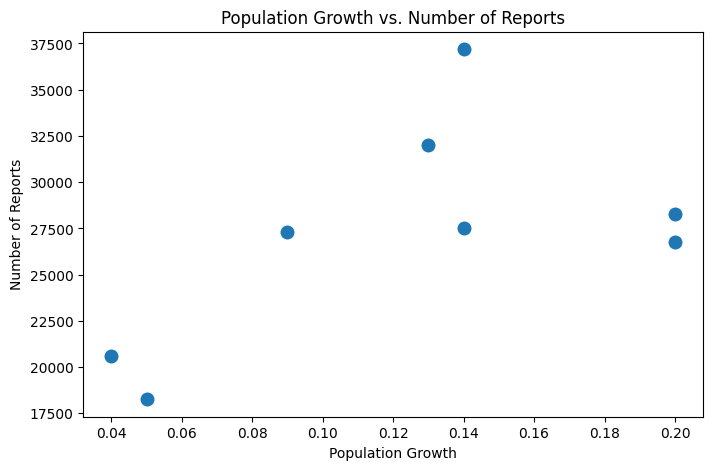

In [576]:
plt.figure(figsize=(8,5))
sns.scatterplot(dfDistricts, x="Population_Growth", y="NumReports", s=120)
plt.title("Population Growth vs. Number of Reports")
plt.xlabel("Population Growth")
plt.ylabel("Number of Reports")
plt.show()

We can see that there is a slight correlation between population growth and number of reports, with districts that had low population growth having far fewer reports

### Cross Tabulation of Population Growth and Income per Household

Finally, let's do a cross tabulation of income and population growth to see if we can find any interesting insights between the two features.

In [577]:
Growth = pd.cut(
    dfDistricts["Population_Growth"],
    bins=[-1, 0.05, 0.15, 0.30],
    labels=["Low Growth", "Medium Growth", "High Growth"]
)

Income = pd.cut(
    dfDistricts["Income per Household"],
    bins=[0, 20000, 30000, 40000],
    labels=["Low", "Mid", "High"]
)

pd.crosstab(Growth, Income)

Income per Household,Low,Mid,High
Population_Growth,,,
Low Growth,0,1,1
Medium Growth,0,2,2
High Growth,1,1,0


This cross tabulation table shows us how population growth rates roughly translate to income per household. Using these binds helps us to get a rough idea of how these two variables are or aren't related. By observing the table, we can see that high population growth generally yields a lower average income per household.

### Model Plan

Now that we have all of our data loaded, cleaned, and combined, we will use this data to build a predictive model using sklearn's Random Forest Regressor
* Label to be predicted: Number of reports in a district in a month
* Features: Population, Age, Population Growth, Income Per Household, Month, District

We anticipate that this model will show that regional demographic data can be utilized to predict police call and report volume, aiding policymakers and government leaders who want to reduce crime.

In [578]:
display(dfDistricts)
display(calls_and_reports)

,District,Population,Age,Population_Growth,Income per Household,NumReports
0,1,39886,34.20,0.09,21297.00,27280
1,2,49134,30.50,0.04,25459.97,20623
2,3,53556,36.90,0.14,38620.72,37190
3,4,55150,35.20,0.05,34856.05,18262
4,5,59564,35.00,0.20,24931.19,26783
5,6,60855,36.97,0.14,24839.29,27535
6,7,54108,32.57,0.13,35092.83,32015
7,8,18511,37.35,0.20,17408.99,28264


,District,Location,Signal_Type,Signal_Description,Occurred_Month
0,3,Paris Av & Lafreniere St,21,COMPLAINT,06
1,3,025XX Gladiolus St,103,DISTURBANCE,06
2,7,078XX Read Bd,103D,"DISTURBANCE, DOMESTIC",06
3,6,022XX Jackson Av,43MB,NaN,06
4,2,082XX Earhart Bd,67S,THEFT BY SHOPLIFTING,06
...,...,...,...,...,...
217947,6,S Claiborne Av & Josephine St,20I,INJURY ACCIDENT,08
217948,1,006XX Blk S Telemachus St,21,COMPLAINT,08
217949,5,St Roch Av & N Villere St,21,COMPLAINT,08
217950,5,020XX Blk Louisa St,21,COMPLAINT,08


Let's Scale the Number of Reports by the populations of the districts.

In [579]:
dfDistricts['ReportsPer1000'] = dfDistricts['NumReports'] / (dfDistricts['Population'] / 1000)

Let's Take another look at our data with the scaled number of reports

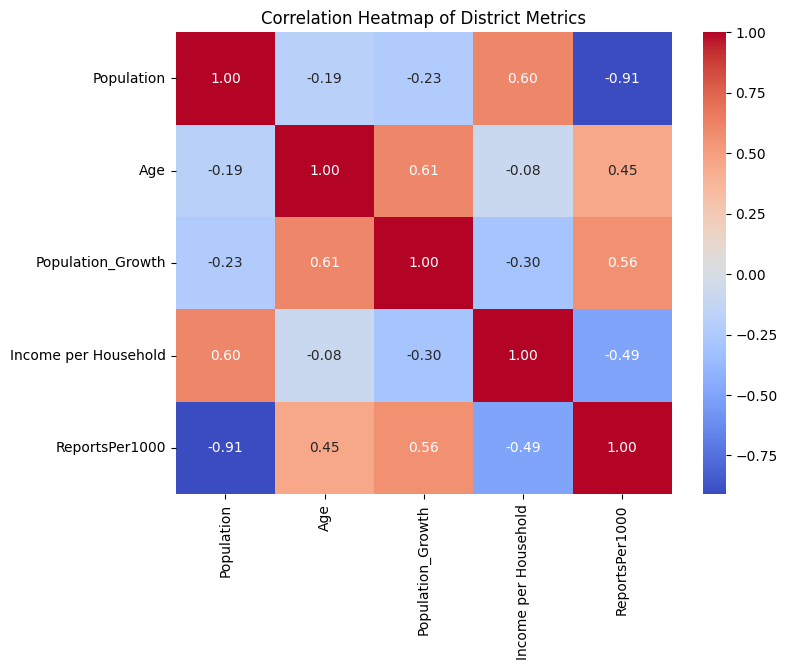

In [580]:
plt.figure(figsize=(8,6))
sns.heatmap(dfDistricts.drop(['District', 'NumReports'], axis=1).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of District Metrics")
plt.show()

Here we can see a few interesting takeaways:
* Income per Household is negatively correlated with reports per 1000 people and population growth
* Age is positively correlated with population growth and reports per 1000 people

Now, we will start building our model

We'll start by grouping our data by month and district, as this will give us more training data with which to build our model. Instead of predicting the total number of calls and reports in a year per district (8 rows), we will predict the total number of reports in a given month by district (96 rows)

In [581]:
crGroupbyDF = calls_and_reports.groupby(['District', 'Occurred_Month']).size().reset_index(name="NumReportsMonth")

monthlyDF = crGroupbyDF.merge(dfDistricts, how="left", on='District').drop(['NumReports'], axis=1)

Let's check the datatypes to see if we need to fix anything before we build our final model

In [582]:
monthlyDF.dtypes

District                  int64
Occurred_Month           object
NumReportsMonth           int64
Population                int32
Age                     float64
Population_Growth       float64
Income per Household    float64
ReportsPer1000          float64
dtype: object

Occurred Month should be an integer, let's change that:

In [583]:
monthlyDF["Occurred_Month"] = monthlyDF["Occurred_Month"].astype(int)

Now we will calculate a one month lag and a percentage change from previous month for our initial model. While this could be considered peaking, especially since these values are being calculated prior to the splitting of the data, these are still metrics that could be used by policymakers to help with call and report volume prediction, so we will do one model with these features and one without.

In [584]:
df = monthlyDF.copy()

# Sort by district and month
df = df.sort_values(["District", "Occurred_Month"])

# Lag 1 month
df["Lag1"] = df.groupby("District")["NumReportsMonth"].shift(1)

# Month-to-month percent change
df["PctChange"] = df.groupby("District")["NumReportsMonth"].pct_change()

# Drop first month of each district which has NaN lags
df = df.dropna()

# Drop December since we do not have enough data for that month
df = df.drop(df.loc[df["Occurred_Month"] == 12].index, axis=0)
df.head()

,District,Occurred_Month,NumReportsMonth,Population,Age,Population_Growth,Income per Household,ReportsPer1000,Lag1,PctChange
1,1,2,2120,39886,34.2,0.09,21297.0,683.949255,2202.0,-0.037239
2,1,3,2614,39886,34.2,0.09,21297.0,683.949255,2120.0,0.233019
3,1,4,2453,39886,34.2,0.09,21297.0,683.949255,2614.0,-0.061591
4,1,5,2599,39886,34.2,0.09,21297.0,683.949255,2453.0,0.059519
5,1,6,2495,39886,34.2,0.09,21297.0,683.949255,2599.0,-0.040015


Finally, in order for us to get value out of the occurred month and district features, we will use pandas get_dummies function to create a one-hot-encoding for these features

In [585]:
df = pd.get_dummies(df, columns=["Occurred_Month"], prefix="Month")
df = pd.get_dummies(df, columns=["District"], prefix="District")

In [586]:
df

,NumReportsMonth,Population,Age,Population_Growth,Income per Household,ReportsPer1000,Lag1,PctChange,Month_2,Month_3,...,Month_10,Month_11,District_1,District_2,District_3,District_4,District_5,District_6,District_7,District_8
1,2120,39886,34.20,0.09,21297.00,683.949255,2202.0,-0.037239,True,False,...,False,False,True,False,False,False,False,False,False,False
2,2614,39886,34.20,0.09,21297.00,683.949255,2120.0,0.233019,False,True,...,False,False,True,False,False,False,False,False,False,False
3,2453,39886,34.20,0.09,21297.00,683.949255,2614.0,-0.061591,False,False,...,False,False,True,False,False,False,False,False,False,False
4,2599,39886,34.20,0.09,21297.00,683.949255,2453.0,0.059519,False,False,...,False,False,True,False,False,False,False,False,False,False
5,2495,39886,34.20,0.09,21297.00,683.949255,2599.0,-0.040015,False,False,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,2463,18511,37.35,0.20,17408.99,1526.875912,2227.0,0.105972,False,False,...,False,False,False,False,False,False,False,False,False,True
91,2850,18511,37.35,0.20,17408.99,1526.875912,2463.0,0.157125,False,False,...,False,False,False,False,False,False,False,False,False,True
92,2635,18511,37.35,0.20,17408.99,1526.875912,2850.0,-0.075439,False,False,...,False,False,False,False,False,False,False,False,False,True
93,2798,18511,37.35,0.20,17408.99,1526.875912,2635.0,0.061860,False,False,...,True,False,False,False,False,False,False,False,False,True


Now, let's prepare our features and labels

In [587]:
features = ['Population', 'Age', 'Population_Growth', 'Income per Household', 'Lag1', 'PctChange', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'District_1', 'District_2', 'District_3', 'District_4', 'District_5', 'District_6', 'District_7', 'District_8']

X = df[features]
y = df['NumReportsMonth']

We'll split the training and test data so that we have a test set with which we can evaluate our model

In [588]:
from sklearn.model_selection import train_test_split

xTrain, xTest, yTrain, yTest = train_test_split(X, y, train_size=.8, random_state=0)

We'll use sklearn's RandomForestRegressor as our model and get the mean absolute error from the predictions the model makes. We chose a Random Forest model because this is an extremely powerful model, even given limited data. We can also extract feature importances from a random forest model, so this will help us to answer our research question about the importance of regional demographic data.

In [589]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=0
)

rf.fit(xTrain, yTrain)
rfPred = rf.predict(xTest)

print("RF MAE:", mean_absolute_error(yTest, rfPred))

RF MAE: 91.4490973274341


In [590]:
yTrain.std()

np.float64(564.4391686876536)

Our model was able to predict call and report volume by month with a Mean Absolute Error of ~91.5, which is pretty good considering the standard deviation of our label data is 564.

Let's examine the feature importances

In [591]:
import numpy as np
importances = rf.feature_importances_

indices = np.argsort(importances)[::-1]

feature_names = xTrain.columns

pd.DataFrame({
    "Feature": feature_names[indices],
    "Importance": importances[indices]
})

,Feature,Importance
0,Lag1,0.574451
1,Population_Growth,0.170827
2,Income per Household,0.163115
3,PctChange,0.065538
4,District_3,0.003713
5,Population,0.003363
6,Month_11,0.003296
7,Age,0.003139
8,District_7,0.001656
9,Month_8,0.001647


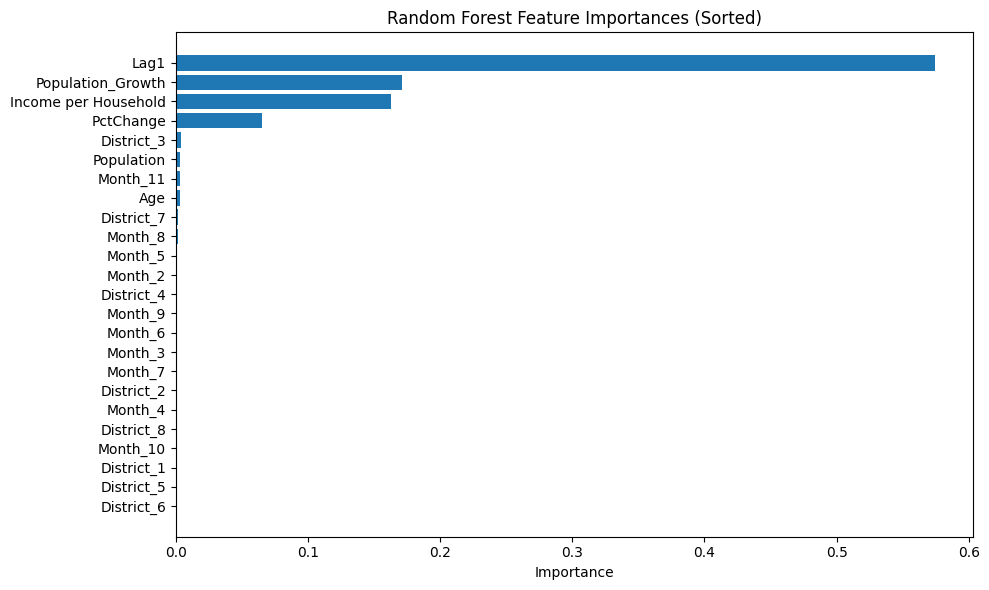

In [592]:
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances (Sorted)")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), xTrain.columns[indices])
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

We can see that the most important features are our lag1, pctchange, population growth, and income per household features. The model seems to be relying pretty heavily on the Lag1 feature, which is not ideal since as noted before, lag1 and pctchange could be considered peaking. This model also does not help us to fully understand the importance of regional demographic features.

So, let's try the model without these variables so that we have a model that does not "peek" at the test data and only uses regional demographic data

In [593]:
# Copy our original dataframe so we do not lose data that was neccessary to drop for the lag variable calculations
dfNoPeek = monthlyDF.copy()

# Drop December since we do not have enough data to include that in our model
dfNoPeek = dfNoPeek.drop(dfNoPeek.loc[dfNoPeek["Occurred_Month"] == 12].index, axis=0)

dfNoPeek = pd.get_dummies(dfNoPeek, columns=["Occurred_Month"], prefix="Month")
dfNoPeek = pd.get_dummies(dfNoPeek, columns=["District"], prefix="District")

dfNoPeek.head()

,NumReportsMonth,Population,Age,Population_Growth,Income per Household,ReportsPer1000,Month_1,Month_2,Month_3,Month_4,...,Month_10,Month_11,District_1,District_2,District_3,District_4,District_5,District_6,District_7,District_8
0,2202,39886,34.2,0.09,21297.0,683.949255,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,2120,39886,34.2,0.09,21297.0,683.949255,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
2,2614,39886,34.2,0.09,21297.0,683.949255,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
3,2453,39886,34.2,0.09,21297.0,683.949255,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,2599,39886,34.2,0.09,21297.0,683.949255,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


In [594]:
featuresNoPeek = ['Population', 'Age', 'Population_Growth', 'Income per Household', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'District_1', 'District_2', 'District_3', 'District_4', 'District_5', 'District_6', 'District_7', 'District_8']
X = dfNoPeek[featuresNoPeek]
y = dfNoPeek['NumReportsMonth']
xTrain, xTest, yTrain, yTest = train_test_split(X, y, train_size=.8, random_state=0)

rf.fit(xTrain, yTrain)
rfPred = rf.predict(xTest)

print("RF MAE:", mean_absolute_error(yTest, rfPred))

RF MAE: 156.48664103558065


Eliminating peeking did significantly reduce the accuracy of our model, but this was expected. A MAE of 156.4 is still not terrible compared to the standard deviation of ~564. Let's check out the feature importances

In [595]:
importances = rf.feature_importances_

indices = np.argsort(importances)[::-1]

feature_names = xTrain.columns

pd.DataFrame({
    "Feature": feature_names[indices],
    "Importance": importances[indices]
})

,Feature,Importance
0,Population_Growth,0.501596
1,Income per Household,0.334375
2,District_3,0.028925
3,Month_2,0.027207
4,Month_11,0.026246
5,Month_8,0.016422
6,Age,0.013808
7,Month_10,0.010176
8,Population,0.007476
9,District_7,0.007171


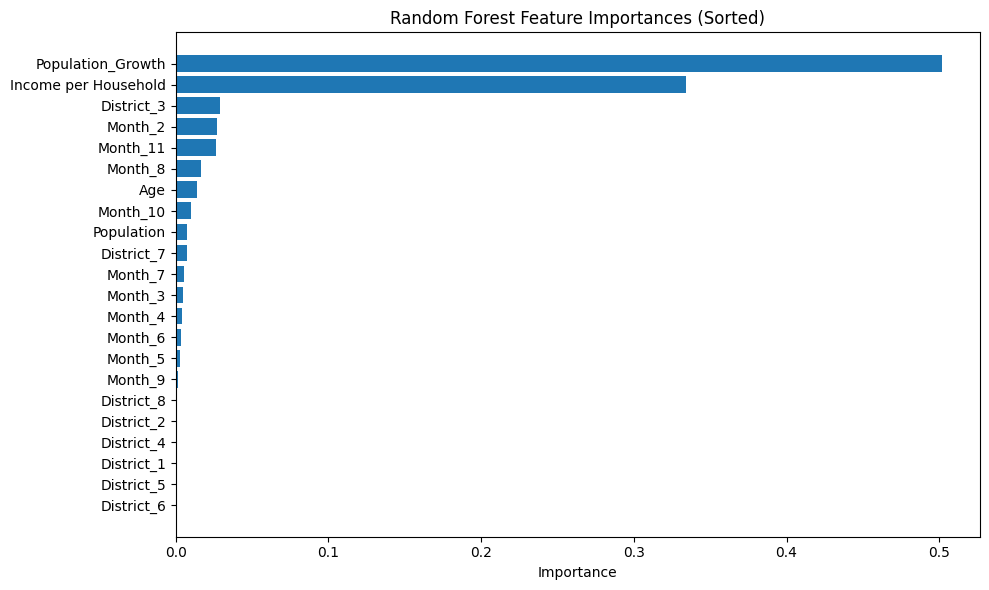

In [596]:
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances (Sorted)")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), xTrain.columns[indices])
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

We can see that the most important factors are population growth and income per household. These regional demographic features are therefore very useful to policy makers, activists, and civil servants for predicting call and report volume.

Other interesting takeaways from our model:
* District 3 is the next most important feature, and district 3 is the wealthiest district in New Orleans
* Month 2 is the next most important feature after District 3, and Month 2 is February, which was when Mardi Gras occurred this year.

Finally, let's mess around with the parameters of our model to see if we can do any better. This will be similar to a sklearn's GridSearchCV, but instead of a Cross Validation, we will be using our test set to evaluate the models

In [602]:
lowestMAE = float('inf')
bestParameterCombo = [-1, -1] # n_estimators, max_depth

n_estimatorsList = [150, 175, 200, 225, 250, 275, 300, 325]
max_depthList = range(1,10)

for i in range(len(n_estimatorsList)):
    for j in range(len(max_depthList)):
          rf = RandomForestRegressor(
			n_estimators=n_estimatorsList[i],
			max_depth=max_depthList[j],
			random_state=0
		)
          rf.fit(xTrain, yTrain)
          rfPred = rf.predict(xTest)
          mae = mean_absolute_error(yTest, rfPred)
          if mae < lowestMAE:
             lowestMAE = mae
             bestParameterCombo[0] = n_estimatorsList[i]
             bestParameterCombo[1] = max_depthList[j]
			

print(f"Best Combination:\nn_estimators: {bestParameterCombo[0]}\nmax_depth: {bestParameterCombo[1]}\nMAE: {lowestMAE}")

Best Combination:
n_estimators: 200
max_depth: 5
MAE: 148.82304624203232


Awesome, with a bit of extra effort, we were able to get the MAE of our final model below 150!

Although this is still significantly worse than the original peeking model, it is certainly still acceptable to answer our research question. 

In summary, our model supports the conclusion that crime and police call and report volume are issues where data science can help turn an obscure social issue into a predictable and manageable issue. Further analysis that uses more data from different years and different cities is certainly possible, and would help us to gain an even further understanding of how police report volume is related to regional demographic data.